In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
extract = "/content/drive/MyDrive/groove"

In [3]:
import os
extract = "/content/drive/MyDrive/groove"
files = os.listdir(extract)
print(files)

['groove']


In [4]:

import os
new_extactr = "/content/drive/MyDrive/groove/groove"

files = os.listdir(new_extactr)
print(files)

['drummer8', 'drummer6', 'drummer1', 'drummer7', 'drummer10', 'drummer9', 'LICENSE', 'Icon\r', 'README', 'drummer2', 'drummer5', 'drummer4', 'drummer3', 'info.csv']


In [5]:
import os

dataset_path = new_extactr
midi_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".mid"):
            midi_files.append(os.path.join(root, file))

print("Total MIDI files found:", len(midi_files))

Total MIDI files found: 1150


In [6]:
!pip install pretty_midi numpy scikit-learn torch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 76.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.3 MB/s eta 0:00:00


Dataset shape: (11515, 64, 9)
Max value: 1.0
Non-zero elements: 269361
Sparsity: 0.9593885692574903


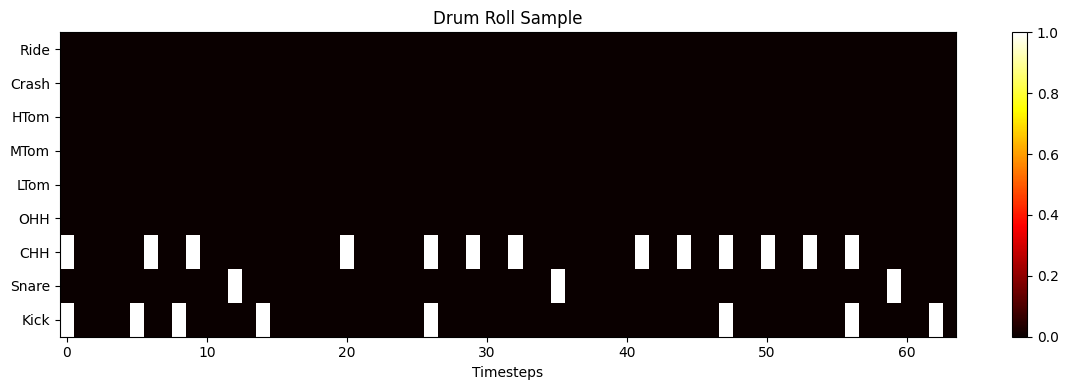

In [ ]:
import pretty_midi
import numpy as np

SEQUENCE_LENGTH = 64
FS = 16  # 16 steps per second

DRUM_PITCHES = [36, 38, 42, 46, 41, 43, 45, 49, 51]


def midi_to_drum_roll(midi_path, fs=FS):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        duration = midi.get_end_time()
        if duration < 0.1:
            return None

        n_steps = int(duration * fs) + 1
        drum_roll = np.zeros((n_steps, len(DRUM_PITCHES)), dtype=np.float32)

        for instrument in midi.instruments:
            if instrument.is_drum:
                for note in instrument.notes:
                    if note.pitch in DRUM_PITCHES:
                        step = int(note.start * fs)
                        pitch_idx = DRUM_PITCHES.index(note.pitch)
                        if step < n_steps:
                            drum_roll[step, pitch_idx] = 1.0

        return drum_roll
    except:
        return None

def segment_sequence(roll, seq_len=SEQUENCE_LENGTH):
    segments = []
    for start in range(0, roll.shape[0] - seq_len, seq_len):
        seg = roll[start:start + seq_len]
        # Only keep segments that have at least some notes
        if seg.sum() > 4:
            segments.append(seg)
    return segments

# Rebuild dataset
all_segments = []

for path in midi_files:
    roll = midi_to_drum_roll(path)
    if roll is not None and roll.shape[0] >= SEQUENCE_LENGTH:
        segs = segment_sequence(roll)
        all_segments.extend(segs)

all_segments = np.array(all_segments)
print("Dataset shape:", all_segments.shape)

# Verify data
print("Max value:", all_segments.max())
print("Non-zero elements:", (all_segments > 0).sum())
print("Sparsity:", 1 - (all_segments > 0).sum() / all_segments.size)

# Visualize
import matplotlib.pyplot as plt
sample = all_segments[0]
plt.figure(figsize=(12, 4))
plt.imshow(sample.T, aspect='auto', origin='lower', cmap='hot')
plt.colorbar()
plt.yticks(range(len(DRUM_PITCHES)), ['Kick','Snare','CHH','OHH','LTom','MTom','HTom','Crash','Ride'])
plt.title("Drum Roll Sample")
plt.xlabel("Timesteps")
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn

INPUT_SIZE = 9   
HIDDEN_SIZE = 256
LATENT_SIZE = 64
SEQ_LEN = 64

class LSTMAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq_len = SEQ_LEN

        # Encoder: fϕ(X) → z
        self.encoder_lstm = nn.LSTM(INPUT_SIZE, HIDDEN_SIZE, num_layers=2,
                                     batch_first=True, dropout=0.3)
        self.fc_latent = nn.Linear(HIDDEN_SIZE, LATENT_SIZE)

        # Decoder: gθ(z) → X̂
        self.fc_decode = nn.Linear(LATENT_SIZE, HIDDEN_SIZE)
        self.decoder_lstm = nn.LSTM(INPUT_SIZE + LATENT_SIZE, HIDDEN_SIZE, num_layers=2,
                                     batch_first=True, dropout=0.3)
        self.output_layer = nn.Linear(HIDDEN_SIZE, INPUT_SIZE)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        z = self.fc_latent(h_n[-1])
        return z

    def decode(self, z, target=None):
        batch_size = z.size(0)
        inp = torch.zeros(batch_size, 1, INPUT_SIZE).to(z.device)
        z_exp = z.unsqueeze(1)

        h = self.fc_decode(z).unsqueeze(0).repeat(2, 1, 1)
        c = torch.zeros_like(h)

        outputs = []
        for t in range(self.seq_len):
            lstm_in = torch.cat([inp, z_exp], dim=-1)
            out, (h, c) = self.decoder_lstm(lstm_in, (h, c))
            logit = self.output_layer(out)
            outputs.append(logit)
            if target is not None:
                inp = target[:, t:t+1, :]
            else:
                inp = torch.sigmoid(logit).detach()

        return torch.cat(outputs, dim=1)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z, target=x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMAutoencoder().to(device)
print(model)
print("Using device:", device)

LSTMAutoencoder(
  (encoder_lstm): LSTM(9, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc_latent): Linear(in_features=256, out_features=64, bias=True)
  (fc_decode): Linear(in_features=64, out_features=256, bias=True)
  (decoder_lstm): LSTM(73, 256, num_layers=2, batch_first=True, dropout=0.3)
  (output_layer): Linear(in_features=256, out_features=9, bias=True)
)
Using device: cuda


Train: 9212 | Test: 2303
Epoch [5/50] | Loss: 0.8024 | Active hits: 192
Epoch [10/50] | Loss: 0.7842 | Active hits: 192
Epoch [15/50] | Loss: 0.7577 | Active hits: 192
Epoch [20/50] | Loss: 0.7262 | Active hits: 192
Epoch [25/50] | Loss: 0.6950 | Active hits: 188
Epoch [30/50] | Loss: 0.6763 | Active hits: 129
Epoch [35/50] | Loss: 0.6586 | Active hits: 159
Epoch [40/50] | Loss: 0.6468 | Active hits: 129
Epoch [45/50] | Loss: 0.6296 | Active hits: 131
Epoch [50/50] | Loss: 0.6202 | Active hits: 123


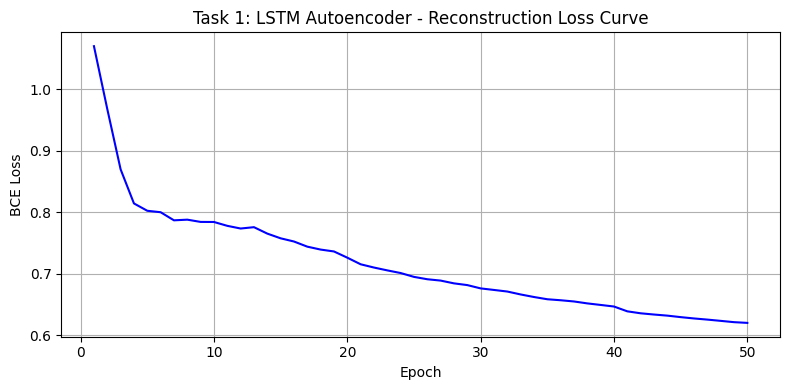

✅ Loss curve saved!


In [9]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

X_tensor = torch.tensor(all_segments, dtype=torch.float32)
dataset = TensorDataset(X_tensor)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Train: {train_size} | Test: {test_size}")

# Sparsity is ~96% so pos_weight=25 to strongly boost note signals
pos_weight = torch.tensor([25.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

EPOCHS = 50
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            sample = torch.tensor(all_segments[:1], dtype=torch.float32).to(device)
            z = model.encode(sample)
            out = torch.sigmoid(model.decode(z))
            active = (out > 0.3).sum().item()
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | Active hits: {active}")

plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, color='blue')
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Task 1: LSTM Autoencoder - Reconstruction Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig("reconstruction_loss.png")
plt.show()
print("✅ Loss curve saved!")

Shape: (64, 9)
Max value: 1.0
Min value: 0.0
Mean value: 0.041666668
Non-zero elements: 24
Total elements: 576
Sparsity: 0.9583333333333334


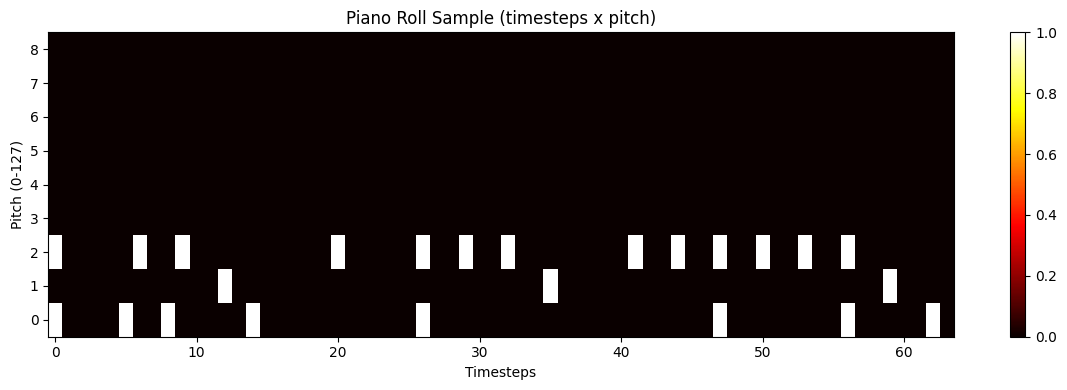

Sample 0 | Non-zero: 24 | Max: 1.0000
Sample 100 | Non-zero: 27 | Max: 1.0000
Sample 500 | Non-zero: 45 | Max: 1.0000
Sample 1000 | Non-zero: 14 | Max: 1.0000


In [10]:
# Diagnose the actual data
sample = all_segments[0]
print("Shape:", sample.shape)
print("Max value:", sample.max())
print("Min value:", sample.min())
print("Mean value:", sample.mean())
print("Non-zero elements:", (sample > 0).sum())
print("Total elements:", sample.size)
print("Sparsity:", 1 - (sample > 0).sum() / sample.size)

# Visualize one segment
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.imshow(sample.T, aspect='auto', origin='lower', cmap='hot')
plt.colorbar()
plt.title("Piano Roll Sample (timesteps x pitch)")
plt.xlabel("Timesteps")
plt.ylabel("Pitch (0-127)")
plt.tight_layout()
plt.show()

# Check a few more samples
for i in [0, 100, 500, 1000]:
    s = all_segments[i]
    print(f"Sample {i} | Non-zero: {(s>0).sum()} | Max: {s.max():.4f}")

Sample 1 | Active hits: 129 | Max: 0.9216


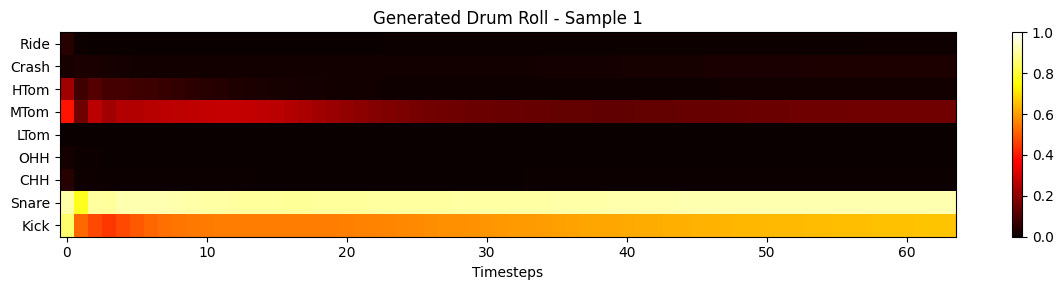

 Saved: generated_midis/generated_sample_1.mid

Sample 2 | Active hits: 112 | Max: 0.8112


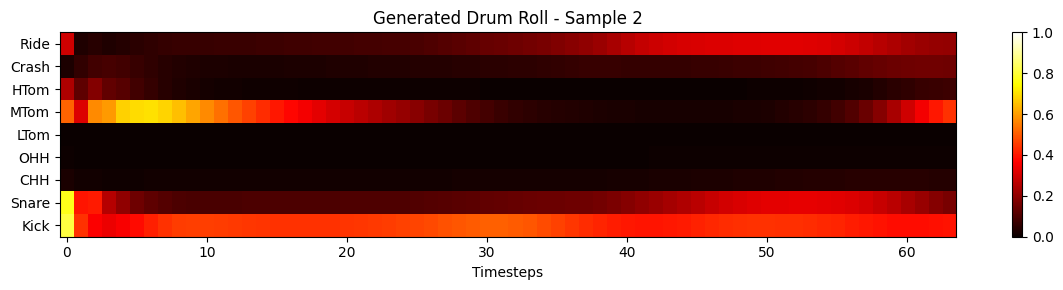

 Saved: generated_midis/generated_sample_2.mid

Sample 3 | Active hits: 208 | Max: 0.7559


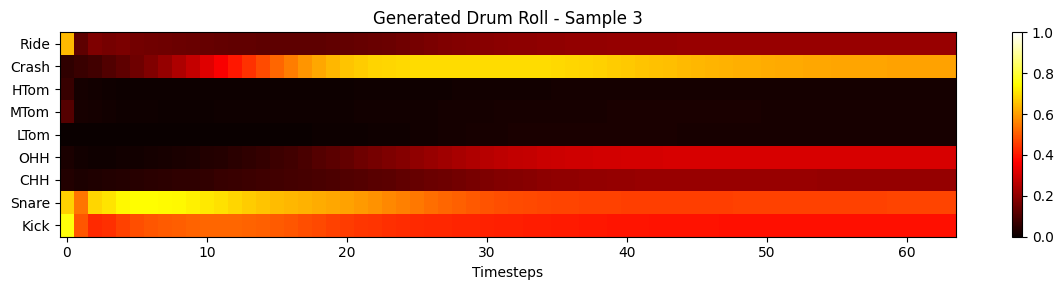

 Saved: generated_midis/generated_sample_3.mid

Sample 4 | Active hits: 276 | Max: 0.8865


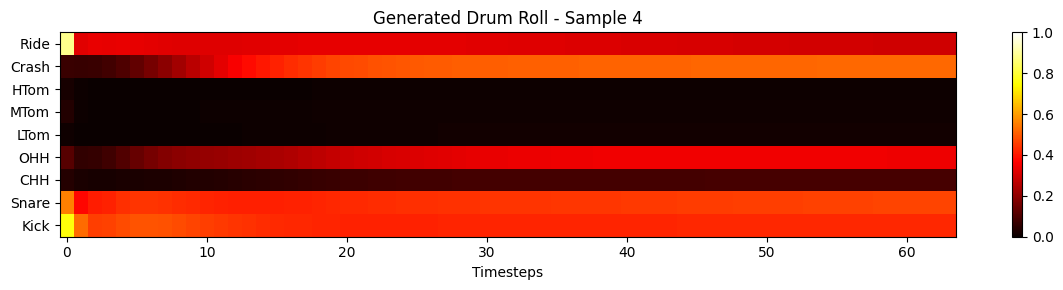

 Saved: generated_midis/generated_sample_4.mid

Sample 5 | Active hits: 184 | Max: 0.8496


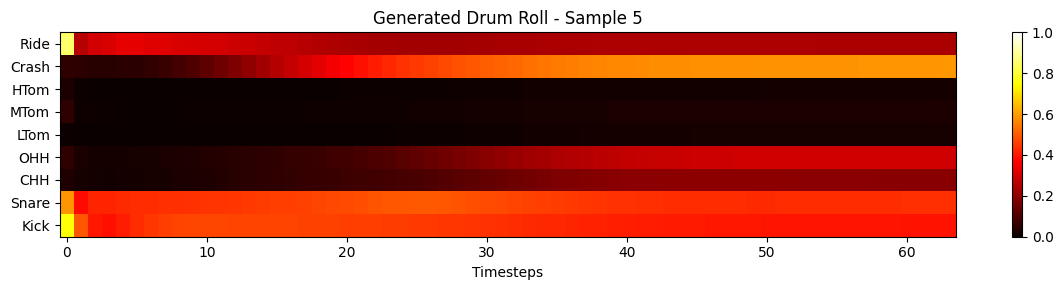

 Saved: generated_midis/generated_sample_5.mid

 All 5 drum MIDI samples generated!


In [11]:
import pretty_midi
import os

os.makedirs("generated_midis", exist_ok=True)

DRUM_PITCHES = [36, 38, 42, 46, 41, 43, 45, 49, 51]
DRUM_NAMES   = ['Kick','Snare','CHH','OHH','LTom','MTom','HTom','Crash','Ride']

def drumroll_to_midi(drum_roll, fs=16, tempo=120.0, threshold=0.3):
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=0, is_drum=True)
    seconds_per_step = 60.0 / (tempo * fs / 4)

    for pitch_idx, pitch in enumerate(DRUM_PITCHES):
        for step in range(drum_roll.shape[0]):
            if drum_roll[step, pitch_idx] > threshold:
                start = step * seconds_per_step
                end   = start + seconds_per_step
                note  = pretty_midi.Note(velocity=100, pitch=pitch, start=start, end=end)
                instrument.notes.append(note)

    midi.instruments.append(instrument)
    return midi

model.eval()
sample_indices = np.random.choice(len(all_segments), 5, replace=False)

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        # Encode real segment + add small noise for variation
        real_seg = torch.tensor(all_segments[idx], dtype=torch.float32).unsqueeze(0).to(device)
        z = model.encode(real_seg)
        z_noisy = z + 0.3 * torch.randn_like(z)

        # Decode
        logits = model.decode(z_noisy)
        generated = torch.sigmoid(logits).squeeze(0).cpu().numpy()  # (64, 9)

        active = (generated > 0.3).sum()
        print(f"Sample {i+1} | Active hits: {active} | Max: {generated.max():.4f}")

        # Visualize drum roll
        plt.figure(figsize=(12, 3))
        plt.imshow(generated.T, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
        plt.colorbar()
        plt.yticks(range(len(DRUM_NAMES)), DRUM_NAMES)
        plt.title(f"Generated Drum Roll - Sample {i+1}")
        plt.xlabel("Timesteps")
        plt.tight_layout()
        plt.show()

        # Save MIDI
        midi_out = drumroll_to_midi(generated)
        path = f"generated_midis/generated_sample_{i+1}.mid"
        midi_out.write(path)
        print(f" Saved: {path}\n")

print(" All 5 drum MIDI samples generated!")

In [12]:
torch.save(model.state_dict(), "lstm_autoencoder.pth")
print(" Model saved: lstm_autoencoder.pth")

 Model saved: lstm_autoencoder.pth


In [13]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/clean_midi.zip"   # change if needed
extract_path = "/content/drive/MyDrive/lakh_midi"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction done!")
else:
    print("Already extracted!")

Extraction done!


In [22]:
new_extactr2 = "/content/drive/MyDrive/lakh_midi/clean_midi/clean_midi"

In [23]:

import os
new_extactr2 = "/content/drive/MyDrive/lakh_midi/clean_midi/clean_midi"

files1 = os.listdir(new_extactr2)
print(files1)

['.38 Special', '10,000 Maniacs', '101 Strings', '10cc', '1910 Fruitgum Company', '2 Brothers on the 4th Floor', '2 the Core', '2 Unlimited', '20 Fingers', '2Boys', '311', '3T', '4 Non Blondes', '702', '808 State', '883', '911', '98 Degrees', 'A Taste of Honey', 'a-ha', 'Aaliyah', 'Aaron Neville', 'ABBA', 'ABC', 'AC DC', 'Ace', 'Ace Frehley', 'Ace of Base', 'Acoustic Alchemy', 'Adam & Eve', 'Adamo', 'Adamski', 'Adiemus', 'Adriano Celentano', 'Adventures of Stevie V.', 'Aerosmith', 'Air Supply', 'AL Bano', 'Al Green', 'Al Hirt', 'Al Jarreau', 'Al Jolson', 'Al Martino', 'Al Stewart', 'Al Wilson', 'Alabama', 'Alain Barriere', 'Alain Bashung', 'Alain Chamfort', 'Alain Souchon', 'Alan Jackson', 'Alan Parsons', 'Alanis Morissette', 'Alannah Myles', 'Albert Hammond', 'Albert West', 'Alberti', 'Alberto Fortis', "Alexander O'Neal", 'Alexander Peter', 'Alexandra', 'Alexia', 'Alice', 'Alice Cooper', 'Alice in Chains', 'Alien Ant Farm', 'Alison Moyet', 'Alive', 'Alizee', 'All Saints', 'All-4-One',

In [24]:
import torch
import torch.nn as nn

INPUT_SIZE = 9   # 9 drum instruments
HIDDEN_SIZE = 256
LATENT_SIZE = 64
SEQ_LEN = 64

class LSTMVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq_len = SEQ_LEN

        # Encoder: qφ(z|X) = N(μ(X), σ(X))
        self.encoder_lstm = nn.LSTM(INPUT_SIZE, HIDDEN_SIZE, num_layers=2,
                                     batch_first=True, dropout=0.3)
        self.fc_mu = nn.Linear(HIDDEN_SIZE, LATENT_SIZE)
        self.fc_log_var = nn.Linear(HIDDEN_SIZE, LATENT_SIZE)

        # Decoder: pθ(X|z)
        self.fc_decode = nn.Linear(LATENT_SIZE, HIDDEN_SIZE)
        self.decoder_lstm = nn.LSTM(INPUT_SIZE + LATENT_SIZE, HIDDEN_SIZE, num_layers=2,
                                     batch_first=True, dropout=0.3)
        self.output_layer = nn.Linear(HIDDEN_SIZE, INPUT_SIZE)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        mu = self.fc_mu(h_n[-1])
        log_var = self.fc_log_var(h_n[-1])
        return mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, target=None):
        batch_size = z.size(0)
        inp = torch.zeros(batch_size, 1, INPUT_SIZE).to(z.device)
        z_exp = z.unsqueeze(1)

        h = self.fc_decode(z).unsqueeze(0).repeat(2, 1, 1)
        c = torch.zeros_like(h)

        outputs = []
        for t in range(self.seq_len):
            lstm_in = torch.cat([inp, z_exp], dim=-1)
            out, (h, c) = self.decoder_lstm(lstm_in, (h, c))
            logit = self.output_layer(out)
            outputs.append(logit)
            if target is not None:
                inp = target[:, t:t+1, :]
            else:
                inp = torch.sigmoid(logit).detach() # Detach for free-running generation

        return torch.cat(outputs, dim=1)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        logits = self.decode(z, target=x)
        return logits, mu, log_var

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vae = LSTMVAE().to(device)
print(model_vae)
print("Using device:", device)


LSTMVAE(
  (encoder_lstm): LSTM(9, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc_mu): Linear(in_features=256, out_features=64, bias=True)
  (fc_log_var): Linear(in_features=256, out_features=64, bias=True)
  (fc_decode): Linear(in_features=64, out_features=256, bias=True)
  (decoder_lstm): LSTM(73, 256, num_layers=2, batch_first=True, dropout=0.3)
  (output_layer): Linear(in_features=256, out_features=9, bias=True)
)
Using device: cuda
